In [239]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
df = yf.download("SPY", start="2004-04-23", end="2025-04-23")
vix = yf.download("^VIX", start="2004-04-23", end="2025-04-23")
df = df.join(vix[['Close']].rename(columns={'Close': 'VIX_Close'}))
df.tail()



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,VIX_Close
Ticker,SPY,SPY,SPY,SPY,SPY,^VIX
Date,,,,,,
2025-04-15,537.609985,543.229980,536.809998,539.669983,56892900,30.120001
2025-04-16,525.659973,537.890015,520.289978,531.679993,83484800,32.639999
2025-04-17,526.409973,531.169983,523.909973,527.640015,79741000,29.650000
2025-04-21,513.880005,521.700012,508.459991,521.159973,69368100,33.820000
2025-04-22,527.250000,529.299988,519.190002,520.140015,75948100,30.570000


In [240]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5283 entries, 2004-04-23 to 2025-04-22
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, SPY)       5283 non-null   float64
 1   (High, SPY)        5283 non-null   float64
 2   (Low, SPY)         5283 non-null   float64
 3   (Open, SPY)        5283 non-null   float64
 4   (Volume, SPY)      5283 non-null   int64  
 5   (VIX_Close, ^VIX)  5283 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 288.9 KB


In [241]:
df.isnull().sum()

,,0
Price,Ticker,
Close,SPY,0
High,SPY,0
Low,SPY,0
Open,SPY,0
Volume,SPY,0
VIX_Close,^VIX,0


In [242]:
df[['Close', 'High', 'Low','Open','Volume']].describe()

Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
count,5283.000000,5283.000000,5283.000000,5283.000000,5.283000e+03
mean,208.835634,209.985731,207.527649,208.810884,1.220969e+08
std,140.263445,140.995235,139.410279,140.246158,9.077975e+07
min,50.379547,51.777540,49.632475,50.261196,1.527000e+07
25%,95.633862,96.363439,94.966081,95.754184,6.347180e+07
50%,163.941727,164.671454,162.925290,163.941678,9.170750e+07
75%,277.471588,279.616532,275.388888,276.938158,1.508687e+08
max,611.091675,611.390763,607.731787,609.705872,8.710263e+08


<Axes: xlabel='Date'>

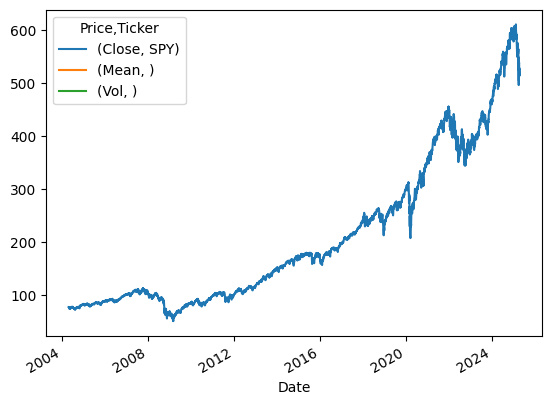

In [243]:
df['Mean'] = df['Close'].mean()
df['Vol'] = df['Close'].std()

df[['Close', 'Mean', 'Vol']].plot()
# obviously not comparable if we trace raw data way back past


Ticker             SPY
Date                  
2004-04-23   77.050957
2004-04-26   76.943153
2004-04-27   77.010551
2004-04-28   76.013382
2004-04-29   75.346359
...                ...
2025-04-15  537.609985
2025-04-16  525.659973
2025-04-17  526.409973
2025-04-21  513.880005
2025-04-22  527.250000

[5283 rows x 1 columns] Date
2004-04-23         NaN
2004-04-26         NaN
2004-04-27         NaN
2004-04-28         NaN
2004-04-29         NaN
                ...   
2025-04-15    0.000379
2025-04-16    0.000298
2025-04-17    0.000327
2025-04-21    0.000240
2025-04-22    0.000379
Name: Rolling_Mean, Length: 5283, dtype: float64 Date
2004-04-23         NaN
2004-04-26         NaN
2004-04-27         NaN
2004-04-28         NaN
2004-04-29         NaN
                ...   
2025-04-15    0.012313
2025-04-16    0.012394
2025-04-17    0.012388
2025-04-21    0.012481
2025-04-22    0.012573
Name: Rolling_Sd, Length: 5283, dtype: float64


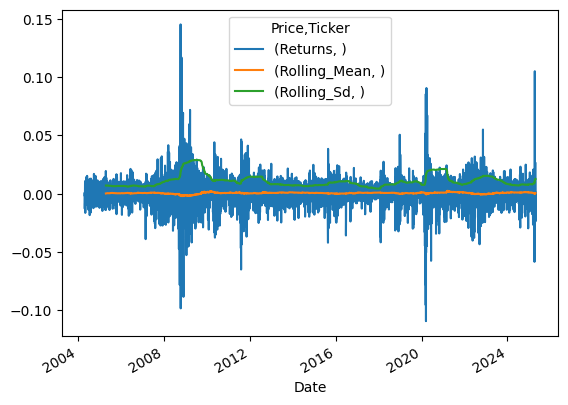

In [244]:
# thus, use rolling window of 1 year for all metrics
# note that there are 251 trading days in a year
df['Returns'] = df['Close'].pct_change()
df['Rolling_Mean'] = df['Returns'].rolling(251).mean()
df['Rolling_Sd'] = df['Returns'].rolling(251).std()
df[['Returns', 'Rolling_Mean', 'Rolling_Sd']].plot()
print(df['Close'], df['Rolling_Mean'], df['Rolling_Sd'])

In [245]:

df['Rolling_Skew'] = df['Returns'].rolling(251).apply(skew, raw=True)
df['Rolling_Kurt'] = df['Returns'].rolling(251).apply(kurtosis, raw=True)

print(df[['Rolling_Skew', 'Rolling_Kurt']].tail())

Price      Rolling_Skew Rolling_Kurt
Ticker                              
Date                                
2025-04-15     1.402717    22.823911
2025-04-16     1.370584    22.230053
2025-04-17     1.366007    22.266275
2025-04-21     1.327813    21.618844
2025-04-22     1.301626    20.914246


In [246]:
# df['HV_20'] = df['Returns'].rolling(20).std()

# # Annualize it (sqrt(252 trading days/year))
# df['HV_20_Annualized'] = df['HV_20'] * np.sqrt(252)
# df[['HV_20', 'HV_20_Annualized']].tail()

In [247]:
df['H-L'] = df['High'] - df['Low']
df['H-PC'] = abs(df['High'] - df['Close'].shift(1))  # Previous Close
df['L-PC'] = abs(df['Low'] - df['Close'].shift(1))
df['TR'] = df[['H-L', 'H-PC', 'L-PC']].max(axis=1)
df['ATR'] = df['TR'].rolling(14).mean()
df[['Close', 'ATR']].tail()

Price,Close,ATR
Ticker,SPY,
Date,,
2025-04-15,537.609985,22.742861
2025-04-16,525.659973,23.574291
2025-04-17,526.409973,23.235005
2025-04-21,513.880005,23.528573
2025-04-22,527.250000,23.968571


In [248]:
# delta = df['Close'].diff()

# # Separate gains and losses
# gain = delta.where(delta > 0, 0)
# loss = -delta.where(delta < 0, 0)

# # Calculate average gain/loss (using simple moving average)
# avg_gain = gain.rolling(14).mean()
# avg_loss = loss.rolling(14).mean()

# # Compute RS and RSI
# rs = avg_gain / avg_loss
# df['RSI'] = 100 - (100 / (1 + rs))
# df[['Close', 'RSI']].describe()

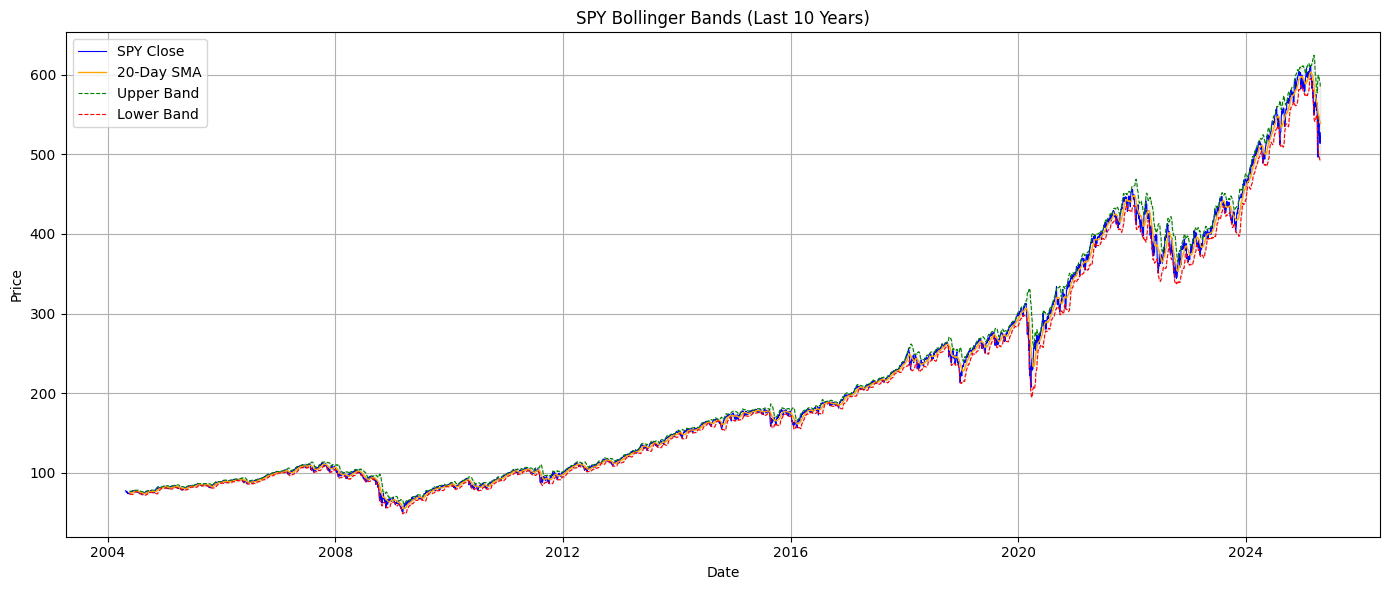

In [249]:
# Price_to_Upper': close_prices / upper_band,
#     'Price_to_Lower': close_prices / lower_band,
#     'Band_Width': (upper_band - lower_band) / sma,
#     '%B': (close_prices - lower_band) / (upper_band - lower_band),
#     'Deviation_from_SMA': (close_prices - sma) / sma,
df['SMA20'] = df['Close'].rolling(window=20).mean()
df['STD20'] = df['Close'].rolling(window=20).std()

# Step 3: Calculate Upper and Lower Bands
df['Upper Band'] = df['SMA20'] + (2 * df['STD20'])
df['Lower Band'] = df['SMA20'] - (2 * df['STD20'])

df['Price to Upper'] = df['Close']['SPY']/ df['Upper Band']
df['Price to Lower'] = df['Close']['SPY'] / df['Lower Band']
df['Band Width'] = (df['Upper Band'] - df['Lower Band']) / df['SMA20']
# df['%B'] = (df['Close']['SPY'] - df['Lower Band']) / (df['Upper Band'] / df['Lower Band'])
# df['Deviation from SMA'] = (df['Close']['SPY'] - df['SMA20']) / df['SMA20']
df.describe()

# Step 4: Plot the Bollinger Bands
plt.figure(figsize=(14, 6))
plt.plot(df['Close'], label='SPY Close', color='blue', linewidth=0.8)
plt.plot(df['SMA20'], label='20-Day SMA', color='orange', linewidth=1)
plt.plot(df['Upper Band'], label='Upper Band', linestyle='--', color='green', linewidth=0.8)
plt.plot(df['Lower Band'], label='Lower Band', linestyle='--', color='red', linewidth=0.8)
plt.fill_between(df.index, df['Lower Band'], df['Upper Band'], color='gray', alpha=0.1)
plt.title('SPY Bollinger Bands (Last 10 Years)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [250]:
df['Absolute Daily Return'] = df['Close'].pct_change().abs()

volatility_threshold = df['Absolute Daily Return'].median()
print(volatility_threshold)

0.005051808120149992


In [251]:
df.head()

Price,Close,High,Low,Open,Volume,VIX_Close,Mean,Vol,Returns,Rolling_Mean,...,TR,ATR,SMA20,STD20,Upper Band,Lower Band,Price to Upper,Price to Lower,Band Width,Absolute Daily Return
Ticker,SPY,SPY,SPY,SPY,SPY,^VIX,,,,,...,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,,,,,
2004-04-23,77.050957,77.192445,76.666915,77.091381,29395700,14.010000,NaN,NaN,NaN,NaN,...,0.525530,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-04-26,76.943153,77.441738,76.538900,77.145283,35515200,14.770000,NaN,NaN,-0.001399,NaN,...,0.902838,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001399
2004-04-27,77.010551,77.563033,76.781471,76.963389,43485500,15.070000,NaN,NaN,0.000876,NaN,...,0.781562,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000876
2004-04-28,76.013382,76.815156,75.797780,76.734303,50165800,16.290001,NaN,NaN,-0.012948,NaN,...,1.212772,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.012948
2004-04-29,75.346359,76.350257,74.894943,75.946003,69687600,16.600000,NaN,NaN,-0.008775,NaN,...,1.455315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.008775


In [252]:
df['Volatility'] = np.where(
    df['Absolute Daily Return'] > volatility_threshold,
    '1',
    '0'
)
print(df['Volatility'])

Date
2004-04-23    0
2004-04-26    0
2004-04-27    0
2004-04-28    1
2004-04-29    1
             ..
2025-04-15    0
2025-04-16    1
2025-04-17    0
2025-04-21    1
2025-04-22    1
Name: Volatility, Length: 5283, dtype: object


<Axes: xlabel='Volatility', ylabel='Band Width'>

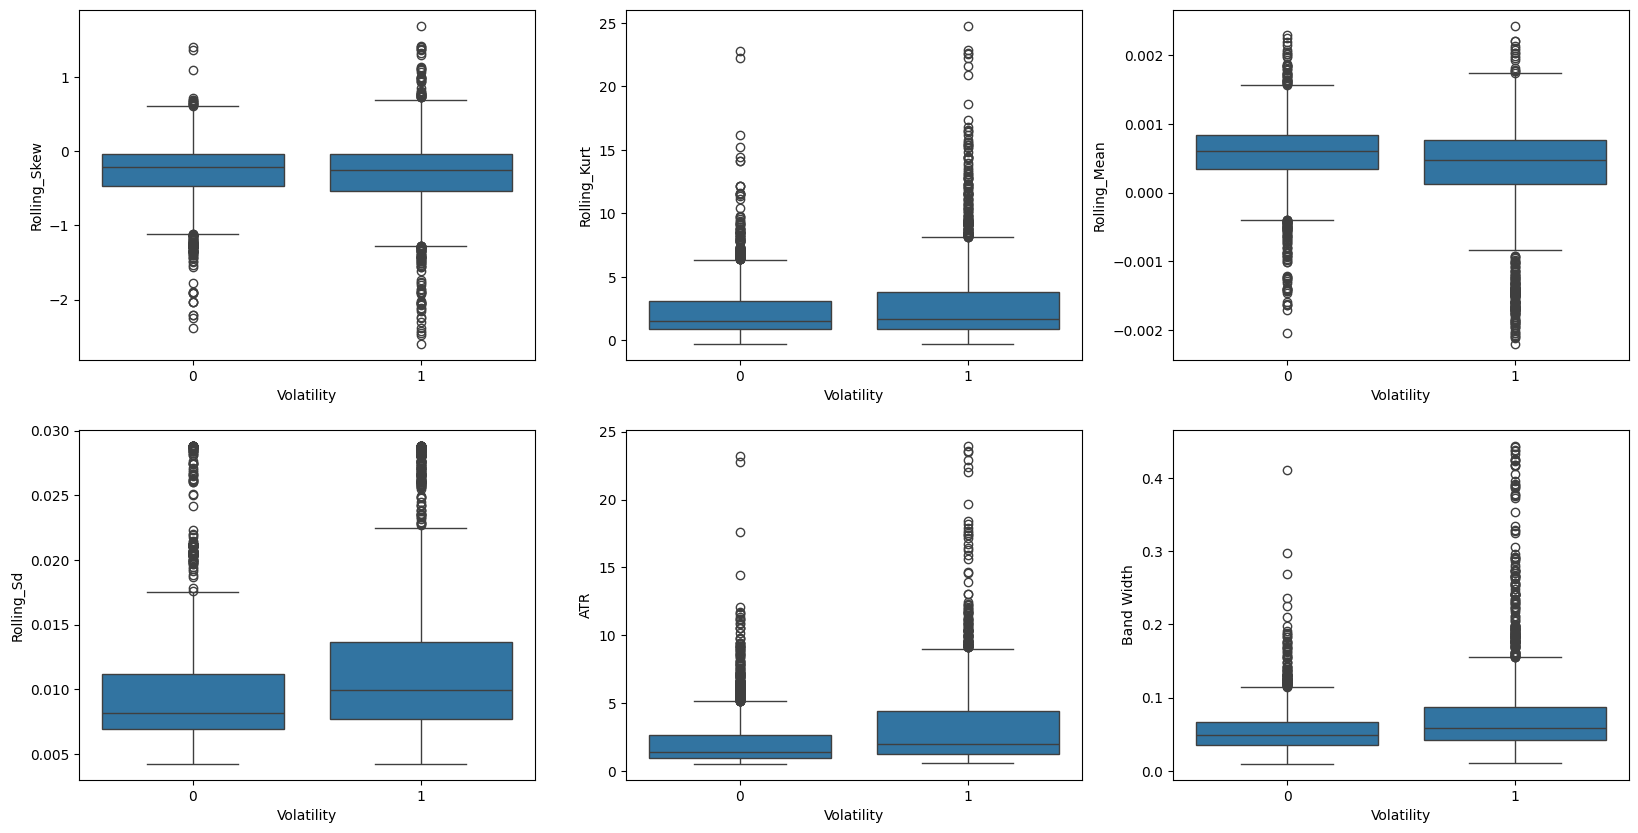

In [253]:
_,axss = plt.subplots(2,3, figsize=[20,10])
sns.boxplot(x='Volatility', y ='Rolling_Skew', data=df, ax=axss[0][0])
sns.boxplot(x='Volatility', y ='Rolling_Kurt', data=df, ax=axss[0][1])
sns.boxplot(x='Volatility', y ='Rolling_Mean', data=df, ax=axss[0][2])
sns.boxplot(x='Volatility', y ='Rolling_Sd', data=df, ax=axss[1][0])
# sns.boxplot(x='Volatility', y ='HV_20_Annualized', data=df, ax=axss[1][0])
sns.boxplot(x='Volatility', y ='ATR', data=df, ax=axss[1][1])
# sns.boxplot(x='Volatility', y ='RSI', data=df, ax=axss[1][2])
sns.boxplot(x='Volatility', y ='Band Width', data=df, ax=axss[1][2])

In [254]:
to_drop = ['Price to Lower','Price to Upper','Absolute Daily Return','SMA20', 'STD20','H-PC', 'H-L', 'L-PC', 'TR','Mean','Vol','Upper Band','Lower Band','Volatility']
X = df.drop(to_drop, axis = 1)

<ipython-input-254-e833afeb1b24>:2: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  X = df.drop(to_drop, axis = 1)


In [255]:
start_date = X.index.min()
cutoff_date = start_date + pd.DateOffset(years=1)

# Keep only data AFTER the cutoff date
X = X[df.index > cutoff_date]

In [256]:
X.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5031 entries, 2005-04-25 to 2025-04-22
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, SPY)       5031 non-null   float64
 1   (High, SPY)        5031 non-null   float64
 2   (Low, SPY)         5031 non-null   float64
 3   (Open, SPY)        5031 non-null   float64
 4   (Volume, SPY)      5031 non-null   int64  
 5   (VIX_Close, ^VIX)  5031 non-null   float64
 6   (Returns, )        5031 non-null   float64
 7   (Rolling_Mean, )   5031 non-null   float64
 8   (Rolling_Sd, )     5031 non-null   float64
 9   (Rolling_Skew, )   5031 non-null   float64
 10  (Rolling_Kurt, )   5031 non-null   float64
 11  (ATR, )            5031 non-null   float64
 12  (Band Width, )     5031 non-null   float64
dtypes: float64(12), int64(1)
memory usage: 550.3 KB


In [257]:
y = df['Volatility']
y = y[y.index > cutoff_date]

In [258]:
from sklearn import model_selection

# split data to training and testing. reserve 25% for testing
# stratify example:
# 100 -> y: 80 '0', 20 '1' -> 4:1
# 80% training 64: '0', 16:'1' -> 4:1
# 20% testing  16:'0', 4: '1' -> 4:1
# 10000 -> 8000 '0' + 2000 '1'

# 25% test 75% training

# without stratified sampling:

# • extreme case:
# testing: 2000 '1' + 500 '0'
# training: 7500 '0'
# with stratified sampling:

# testing: 2000 '0' + 500 '1'
# training: 6000 '0' + 1500 '1'
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2, stratify = y, random_state = 1) #stratified sampling

print('training data has ' + str(X_train.shape[0]) + ' observation with ' + str(X_train.shape[1]) + ' features')
print('test data has ' + str(X_test.shape[0]) + ' observation with ' + str(X_test.shape[1]) + ' features')

training data has 4024 observation with 13 features
test data has 1007 observation with 13 features


In [259]:
from sklearn.preprocessing import StandardScaler
# standardization (x-mean)/std
# avoid large values to affect the model
scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [260]:
print(X_train)

[[-1.07588213 -1.07137194 -1.08056734 ...  1.46464243  0.08301616
   2.53312486]
 [-0.7177086  -0.71769857 -0.71441043 ... -0.40729777 -0.73999875
  -0.02056664]
 [ 2.60757914  2.59233738  2.60804954 ... -0.58404759  0.88406475
  -0.5626523 ]
 ...
 [ 1.58843449  1.57179366  1.58196874 ... -0.17074604  0.71558276
  -0.64601823]
 [ 1.01657312  1.01503367  0.97773237 ... -0.81633005  2.08955587
   1.48783796]
 [-0.74555177 -0.74814153 -0.74263489 ...  0.02982657 -0.62993846
  -0.41139799]]


In [261]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
classifier_logistic = LogisticRegression()

# K Nearest Neighbors
classifier_KNN = KNeighborsClassifier()

# Random Forest
classifier_RF = RandomForestClassifier()

In [262]:
classifier_logistic.fit(X_train, y_train)

LogisticRegression()

In [263]:
classifier_logistic.predict(X_test)

array(['0', '0', '0', ..., '1', '0', '1'], dtype=object)

In [264]:
classifier_logistic.score(X_test, y_test)

0.7040714995034757

In [265]:
from sklearn.model_selection import GridSearchCV

# helper function for printing out grid search results
def print_grid_search_metrics(gs):
    print ("Best score: " + str(gs.best_score_))
    print ("Best parameters set:")
    best_parameters = gs.best_params_
    for param_name in sorted(best_parameters.keys()):
        print(param_name + ':' + str(best_parameters[param_name]))

In [266]:
# Possible hyperparamter options for Logistic Regression Regularization
# Penalty is choosed from L1 or L2
# C is the 1/lambda value(weight) for L1 and L2
# solver: algorithm to find the weights that minimize the cost function
parameters = {
    'penalty':('l2','l1'),
    'C':(0.05, 0.1, 0.2, 1,2,5)
}

Grid_LR = GridSearchCV(LogisticRegression(solver='liblinear'),parameters, cv = 5)
Grid_LR.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

GridSearchCV(cv=5, estimator=LogisticRegression(solver='liblinear'),
             param_grid={'C': (0.05, 0.1, 0.2, 1, 2, 5),
                         'penalty': ('l2', 'l1')})

In [267]:
# the best hyperparameter combination
print_grid_search_metrics(Grid_LR)

Best score: 0.7082515991471215
Best parameters set:
C:2
penalty:l1


In [268]:
best_LR_model = Grid_LR.best_estimator_

In [269]:
best_LR_model.predict(X_test)

array(['0', '0', '0', ..., '0', '0', '0'], dtype=object)

In [270]:
best_LR_model.score(X_test, y_test)

0.7328699106256207

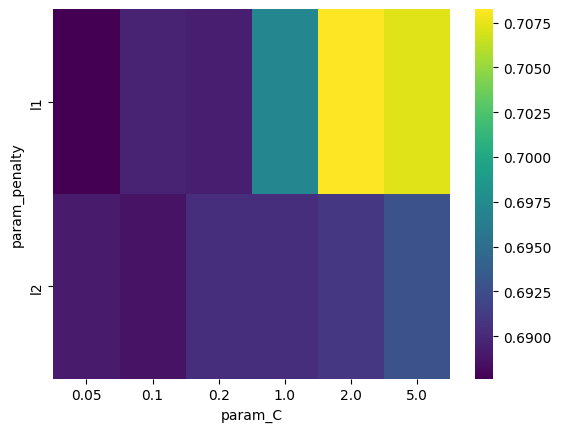

In [271]:
LR_models = pd.DataFrame(Grid_LR.cv_results_)
res = (LR_models.pivot(index='param_penalty', columns='param_C', values='mean_test_score'))
_ = sns.heatmap(res, cmap='viridis')

In [272]:
# Possible hyperparamter options for KNN
# Choose k
parameters = {
    'n_neighbors':[1,3,5,7,9]
}
Grid_KNN = GridSearchCV(KNeighborsClassifier(),parameters, cv=5)
Grid_KNN.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [1, 3, 5, 7, 9]})

In [273]:
print_grid_search_metrics(Grid_KNN)

Best score: 0.8608371187540559
Best parameters set:
n_neighbors:3


In [274]:
best_KNN_model = Grid_KNN.best_estimator_

In [275]:
best_KNN_model.predict(X_test)

array(['0', '1', '0', ..., '0', '1', '1'], dtype=object)

In [276]:
best_KNN_model.score(X_test, y_test)

0.8867924528301887

In [277]:
print(X_train)

[[-1.07588213 -1.07137194 -1.08056734 ...  1.46464243  0.08301616
   2.53312486]
 [-0.7177086  -0.71769857 -0.71441043 ... -0.40729777 -0.73999875
  -0.02056664]
 [ 2.60757914  2.59233738  2.60804954 ... -0.58404759  0.88406475
  -0.5626523 ]
 ...
 [ 1.58843449  1.57179366  1.58196874 ... -0.17074604  0.71558276
  -0.64601823]
 [ 1.01657312  1.01503367  0.97773237 ... -0.81633005  2.08955587
   1.48783796]
 [-0.74555177 -0.74814153 -0.74263489 ...  0.02982657 -0.62993846
  -0.41139799]]


In [278]:
# Possible hyperparamter options for Random Forest
# Choose the number of trees
parameters = {
    'n_estimators' : [20,40,50],
    'max_depth': [1,5,7]

}
Grid_RF = GridSearchCV(RandomForestClassifier(),parameters, cv=5)
Grid_RF.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [1, 5, 7], 'n_estimators': [20, 40, 50]})

In [279]:
# best number of tress
print_grid_search_metrics(Grid_RF)

Best score: 0.9955267142548129
Best parameters set:
max_depth:7
n_estimators:20


In [ ]:
best_RF_model = Grid_RF.best_estimator_

In [ ]:
best_RF_model

RandomForestClassifier(max_depth=7, n_estimators=40)

In [ ]:
best_RF_model.score(X_test, y_test)

0.9980139026812314